# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **¿Cuáles variables son numéricas y cuáles son categóricas?**

**Respuesta:**

- **Numéricas:** `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch` y `Fare`.
- **Categóricas o de texto:** `Name`, `Sex`, `Ticket`, `Cabin` y `Embarked`.

Aunque `Survived` y `Pclass` están almacenadas como números, en el análisis se interpretan como variables categóricas.


# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

En esta base hay **891 pasajeros y 12 características**. La muestra contiene más hombres que mujeres y está concentrada principalmente en tercera clase.


### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


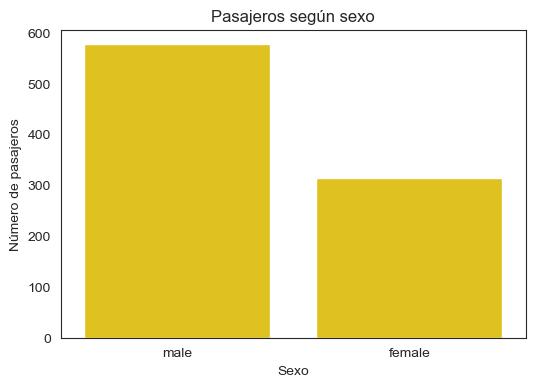

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?

**Respuesta:** La tercera clase es la más numerosa, con 491 pasajeros, seguida por primera (216) y segunda (184). Por lo tanto, la muestra no está balanceada entre las tres clases.


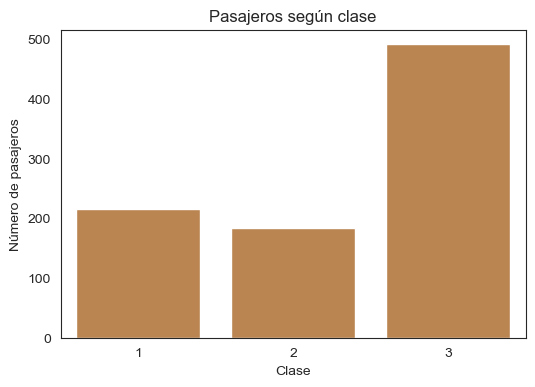

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=titanic, x="Pclass", color="peru")
plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")
plt.show()

titanic["Pclass"].value_counts().sort_index()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?

**Respuesta:** La mayor concentración de pasajeros está entre aproximadamente 20 y 40 años. La distribución no es perfectamente simétrica y presenta una cola hacia edades mayores. Cambiar el número de bins modifica cuánto detalle se observa, pero no cambia el patrón general.


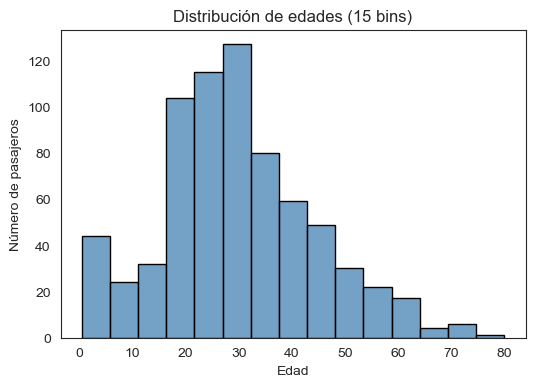

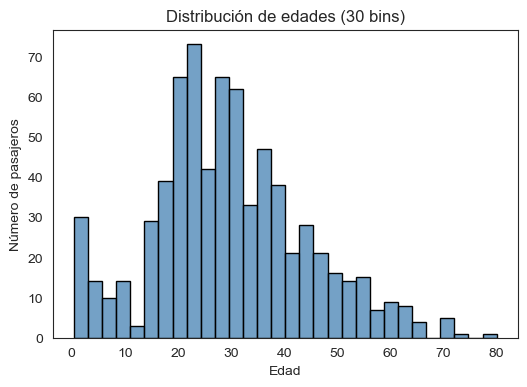

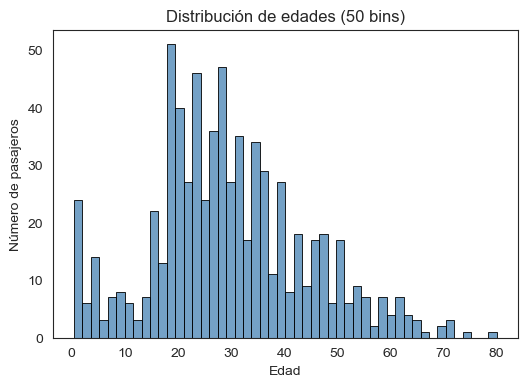

In [5]:
for bins in [15, 30, 50]:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=titanic, x="Age", bins=bins, color="steelblue", edgecolor="black")
    plt.xlabel("Edad")
    plt.ylabel("Número de pasajeros")
    plt.title(f"Distribución de edades ({bins} bins)")
    plt.show()


**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?

**Respuesta:** La distribución de `Fare` es claramente asimétrica hacia valores altos. Existen varias tarifas muy superiores al resto, con un máximo cercano a 512. Esto puede relacionarse con pasajeros de clases más altas o con pasajes que representaban a más de una persona.


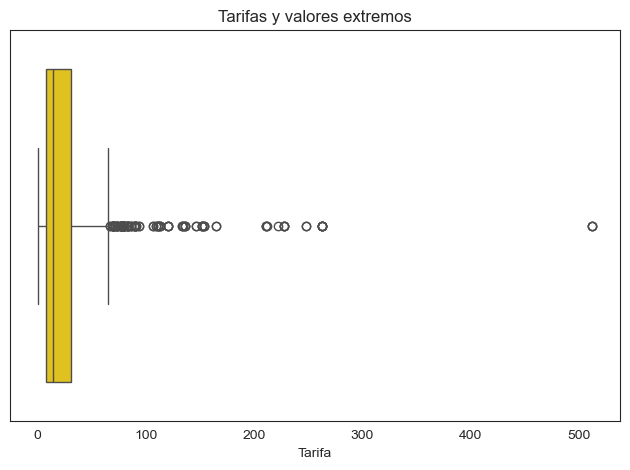

In [6]:
sns.boxplot(data=titanic, x="Fare", color="gold",)
plt.xlabel("Tarifa")
plt.title("Tarifas y valores extremos")

plt.tight_layout()
plt.show()


# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [7]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


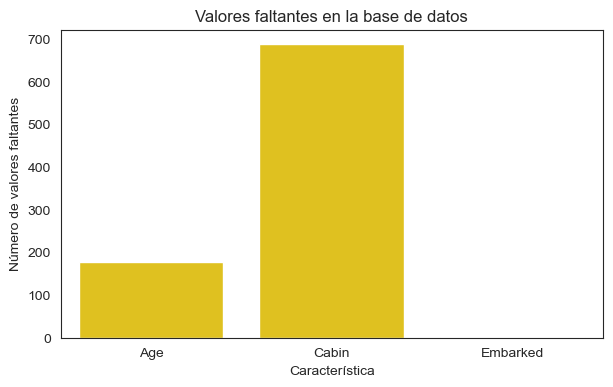

In [8]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()





### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?

**Respuesta:** La media de edad es aproximadamente 29.7 años y la mediana 28 años. Son relativamente cercanas, aunque la media es un poco mayor por la cola hacia edades altas. La media entrega una referencia razonable, pero la mediana es menos sensible a valores extremos.


In [9]:
media_edad = titanic["Age"].mean()
mediana_edad = titanic["Age"].median()

pd.Series({"Media": media_edad, "Mediana": mediana_edad})

Media      29.699118
Mediana    28.000000
dtype: float64

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?

**Respuesta:** No reemplazaría automáticamente todas las edades faltantes por la media, porque eso acumularía artificialmente muchos pasajeros alrededor de una misma edad y reduciría la variabilidad de la distribución. Una alternativa sería imputar usando grupos que nos aporten más información, por ejemplo según `Pclass`, `Sex` o alguna combinación de características, o mantener los faltantes si el análisis lo permite.


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.

**Respuesta:** `Cabin` tiene 687 valores faltantes, por lo que intentar reconstruir todas las cabinas sería poco confiable. Para un análisis simple consideraría eliminar la característica original, pero podría crear una variable como `Cabina_conocida` para estudiar si el hecho de tener registrada una cabina contiene información asociada con clase o supervivencia.


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?

**Respuesta:** Como `Embarked` solo tiene 2 valores faltantes, una estrategia simple sería reemplazarlos por la categoría más frecuente (`S`) o eliminar esas dos filas. El tratamiento puede ser distinto al de `Cabin` porque aquí la proporción de información faltante es mínima.


# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


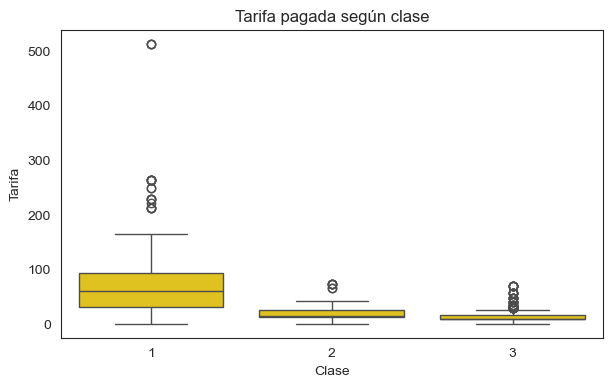

In [10]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?

**Respuesta:** Sí, la tarifa está fuertemente relacionada con la clase: primera clase presenta tarifas más altas y tercera clase las más bajas. Sin embargo, existe dispersión dentro de cada clase y aparecen valores extremos, por lo que `Fare` y `Pclass` están relacionadas pero no contienen exactamente la misma información.


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?

**Respuesta:** Las edades no son iguales entre clases. Los pasajeros de primera clase son, en promedio, mayores (media ≈ 38.2 años), los de segunda tienen una media ≈ 29.9 y los de tercera ≈ 25.1 años. Esto sugiere una relación entre edad y clase.


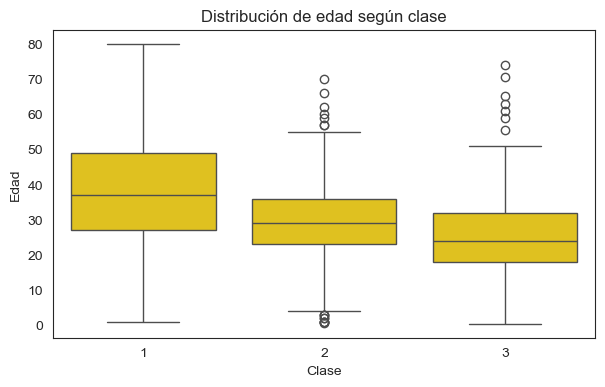

,count,mean,median
Pclass,,,
1,186,38.233441,37.0
2,173,29.877630,29.0
3,355,25.140620,24.0


In [11]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=titanic, x="Pclass", y="Age", color="gold")
plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Distribución de edad según clase")
plt.show()

titanic.groupby("Pclass")["Age"].agg(["count", "mean", "median"])

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [12]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

titanic[["SibSp", "Parch", "Familia"]].head()


,SibSp,Parch,Familia
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?

**Respuesta:** La mayoría de los pasajeros viajaba sola: 537 personas tienen `Familia = 1`. También hay grupos familiares grandes, aunque son poco frecuentes, llegando hasta 11 personas. Mirar solo `SibSp` o `Parch` por separado perdería parte de la información sobre el tamaño total del grupo familiar.


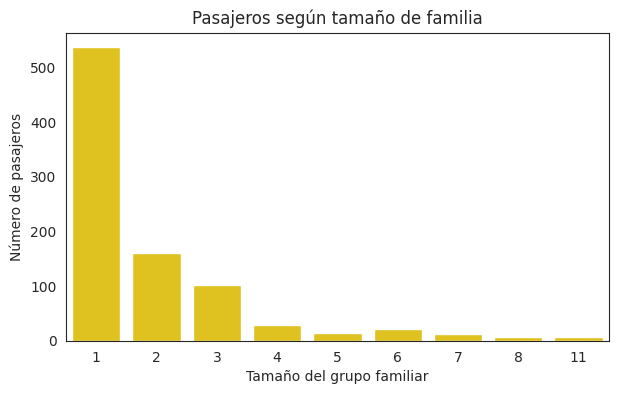

Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [13]:
plt.figure(figsize=(7, 4))
sns.countplot(data=titanic, x="Familia", color="gold")

plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según tamaño de familia")

plt.show()

titanic["Familia"].value_counts().sort_index()


# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


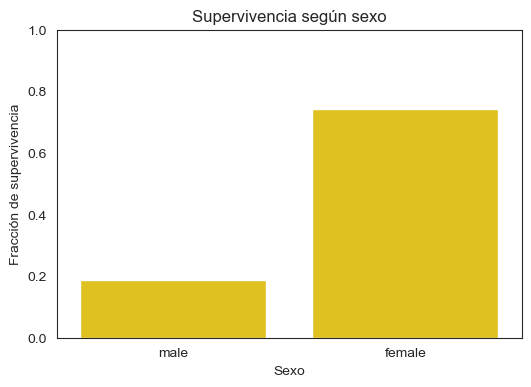

In [13]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?

**Respuesta:** La diferencia es muy marcada: sobrevivió aproximadamente el 74% de las mujeres y el 19% de los hombres. El gráfico muestra una asociación entre sexo y supervivencia, pero por sí solo no permite establecer la causa de esa diferencia.


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?

**Respuesta:** La supervivencia disminuye al pasar de primera a tercera clase: aproximadamente 63% en primera, 47% en segunda y 24% en tercera. Existe una tendencia clara entre clase y supervivencia.


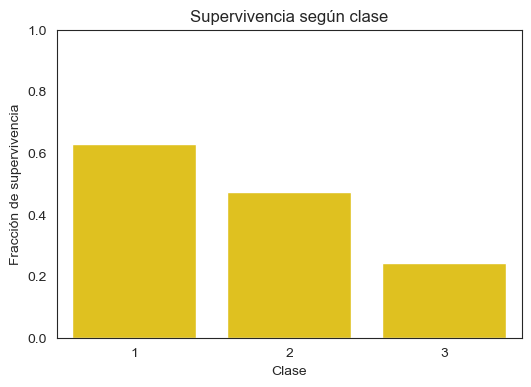

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color="gold")

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0, 1)

plt.show()

titanic.groupby("Pclass")["Survived"].mean()


**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?

**Respuesta:** Las distribuciones se superponen bastante: la mediana es 28 años tanto para sobrevivientes como para no sobrevivientes. Sin embargo, los niños pequeños muestran una fracción de supervivencia relativamente alta, por lo que la relación con edad no parece ser simplemente lineal.


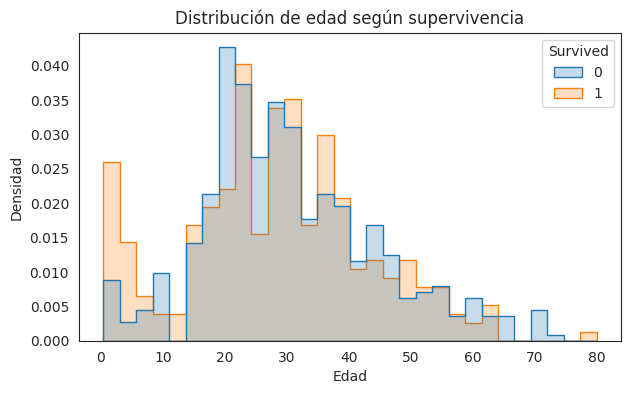

,count,mean,median
Survived,,,
0,424,30.626179,28.0
1,290,28.343690,28.0


In [16]:
plt.figure(figsize=(7, 4))

sns.histplot(data=titanic,
             x="Age",
             hue="Survived",
             bins=30,
             stat="density",
             common_norm=False,
             element="step")

plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.title("Distribución de edad según supervivencia")

plt.show()

titanic.groupby("Survived")["Age"].agg(["count", "mean", "median"])


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?

**Respuesta:** Viajar solo aparece menos favorable que viajar en grupos familiares pequeños: la supervivencia es cerca de 30% para `Familia = 1`, mientras que aumenta para tamaños 2 a 4. La relación no es simple, porque en familias muy grandes la supervivencia vuelve a disminuir y algunos grupos tienen muy pocos pasajeros.


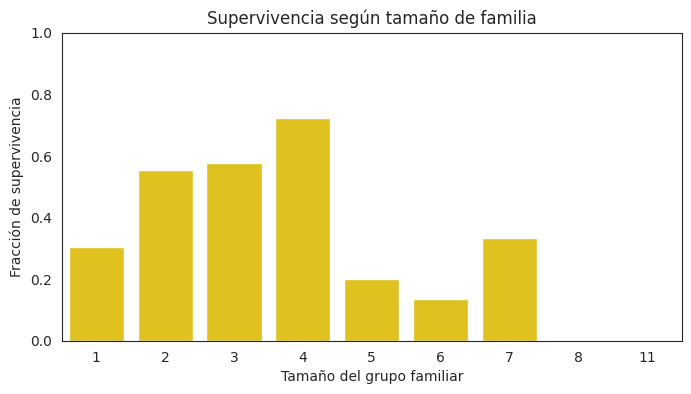

,count,mean
Familia,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


In [17]:
plt.figure(figsize=(8, 4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color="gold")

plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según tamaño de familia")
plt.ylim(0, 1)

plt.show()

titanic.groupby("Familia")["Survived"].agg(["count", "mean"])


# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


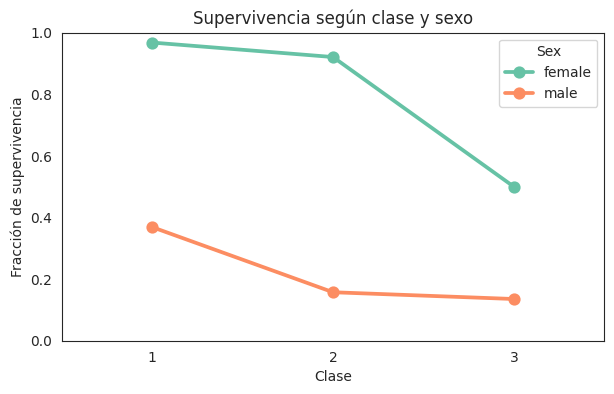

In [18]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?

**Respuesta:** La relación entre clase y supervivencia cambia según el sexo. Las mujeres presentan una supervivencia alta en primera y segunda clase, mientras que los hombres tienen valores mucho menores en todas las clases. Mirar solo una de las dos características ocultaba estas diferencias internas; uno de los grupos más favorecidos son las mujeres de primera clase y uno de los más desfavorecidos son los hombres de tercera.


### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [15]:
# Complete el código

titanic["Persona"] = np.where(titanic["Age"] < 16,
                              "niño/a",
                              np.where(titanic["Sex"] == "female",
                                       "mujer",
                                       "hombre"))

# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?

**Respuesta:** Los niños no siguen exactamente el mismo patrón que los adultos. En segunda clase la supervivencia infantil es especialmente alta, mientras que en tercera disminuye de manera importante. La clase sigue siendo relevante y la mayor supervivencia aparece entre mujeres de primera clase, seguida por mujeres de segunda y niños de segunda clase.


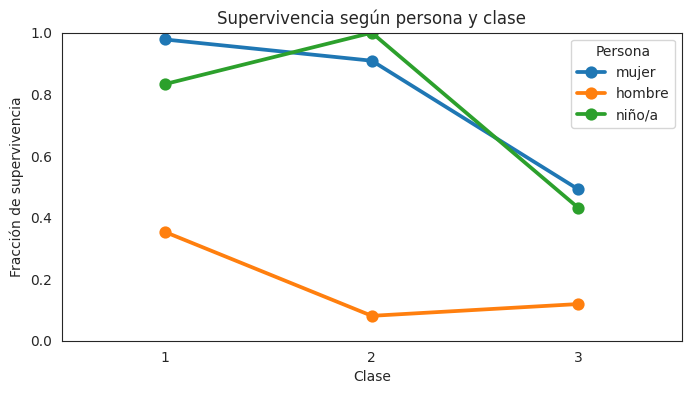

count      mean
Persona Pclass                 
hombre  1         119  0.352941
        2          99  0.080808
        3         319  0.119122
mujer   1          91  0.978022
        2          66  0.909091
        3         114  0.491228
niño/a  1           6  0.833333
        2          19  1.000000
        3          58  0.431034

In [20]:
plt.figure(figsize=(8, 4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según persona y clase")
plt.ylim(0, 1)

plt.show()

titanic.groupby(["Persona", "Pclass"])["Survived"].agg(["count", "mean"])


**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**

**Respuesta:** Al separar por clase se observa que el tamaño familiar no actúa de la misma forma para todos los pasajeros. En tercera clase los grupos familiares grandes presentan una supervivencia especialmente baja, mientras que en primera y segunda clase los grupos pequeños o medianos mantienen fracciones de supervivencia mayores. Esto muestra que la asociación entre familia y supervivencia también depende de la clase.


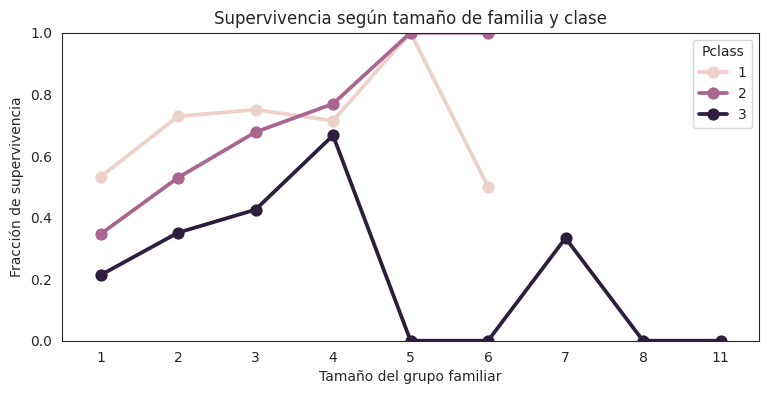

In [21]:
# Pregunta:
# ¿La relación entre tamaño de familia y supervivencia cambia según la clase del pasajero?

# Código:
plt.figure(figsize=(9, 4))

sns.pointplot(data=titanic,
              x="Familia",
              y="Survived",
              hue="Pclass",
              errorbar=None)

plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según tamaño de familia y clase")
plt.ylim(0, 1)

plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.

### Respuestas

**1. ¿Quiénes eran los pasajeros del Titanic?**  
La muestra contiene 891 pasajeros. Predominan los hombres (577 frente a 314 mujeres) y la tercera clase (491 pasajeros). La edad se concentra principalmente entre 20 y 40 años, con una media cercana a 29.7 años. Además, la mayoría viajaba sola (`Familia = 1`), aunque también aparecen grupos familiares de distintos tamaños.

**2. ¿Qué características estaban asociadas con la supervivencia?**  
Las asociaciones más claras aparecen con el sexo y la clase. Las mujeres presentan una supervivencia mucho mayor que los hombres, y la supervivencia disminuye desde primera hacia tercera clase. La edad muestra un patrón menos fuerte, aunque los niños pequeños parecen tener una supervivencia relativamente mayor. Viajar en grupos familiares pequeños o medianos aparece más favorable que viajar solo o pertenecer a un grupo muy grande.

**3. ¿Qué relaciones cambiaron al considerar varias características al mismo tiempo?**  
Al estudiar simultáneamente sexo y clase se observa que la ventaja asociada a ser mujer no es igual en todas las clases. Las mujeres de primera y segunda clase tienen supervivencias muy altas, mientras que en tercera clase disminuyen. También los niños presentan diferencias importantes según clase.

**4. ¿Encontró características que contienen información relacionada?**  
Sí. `Fare` y `Pclass` están relacionadas, porque las tarifas más altas aparecen principalmente en primera clase. También `SibSp` y `Parch` contienen información relacionada sobre acompañantes familiares, por lo que se combinaron en la característica `Familia`.

**5. ¿Qué resultado le pareció más inesperado?**  
**Observación:** los pasajeros de familias pequeñas o medianas presentan mayor supervivencia que quienes viajaban solos, pero la supervivencia disminuye nuevamente en familias grandes.  
**Hipótesis:** una posible explicación es que viajar acompañado facilitara recibir ayuda durante la evacuación, mientras que mantener unido a un grupo familiar muy grande pudiera dificultarla. Esta explicación no puede comprobarse solo con esta base de datos.


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió** en esta muestra fue una mujer, especialmente de primera o segunda clase. Los niños también presentan una supervivencia relativamente alta, aunque esta ventaja disminuye en tercera clase. Además, los grupos familiares pequeños o medianos parecen estar asociados con una mayor supervivencia que viajar solo o pertenecer a una familia muy grande. En conjunto, sexo y clase son las características que muestran las asociaciones más claras con la supervivencia, mientras que edad y tamaño familiar aportan información adicional al considerar el contexto.
